# **Water Quality**
## Team (MIB)

<img class="image1" src="https://d9-wret.s3.us-west-2.amazonaws.com/assets/palladium/production/s3fs-public/styles/info_block/public/media/images/chalkboardQWv3.png?itok=osJJwPW7" style="width:400px;height:200px"/>

## import library



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import sklearn
from scipy import stats
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import sklearn.model_selection as model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest,chi2

In [2]:
ds=pd.read_excel('water_potability.xlsx')

### over view your data

In [3]:
ds.shape

(3276, 10)

In [4]:
ds.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [5]:
ds.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [6]:
ds.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [7]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


## 1) Data Preprocessing

### 1. check null

In [8]:
print(ds.isnull().sum())

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [9]:
missing_PH=(ds.ph.isnull().sum() / ds.shape[0]) * 100
print("The precentage of missing information in PH is :",missing_PH)

missing_Sulfate=(ds.Sulfate.isnull().sum() / ds.shape[0]) * 100
print("The precentage of missing information in Sulfate is :",missing_Sulfate)

missing_Trihalomethanes=(ds.Trihalomethanes.isnull().sum() / ds.shape[0]) * 100
print("The precentage of missing information in Trihalomethanes is :",missing_Trihalomethanes)

The precentage of missing information in PH is : 14.987789987789988
The precentage of missing information in Sulfate is : 23.84004884004884
The precentage of missing information in Trihalomethanes is : 4.945054945054945


<Axes: >

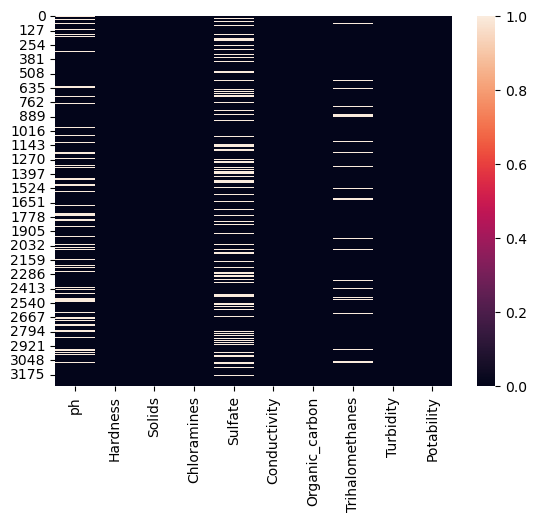

In [10]:
sns.heatmap(ds.isnull())

Text(0.5, 0.98, 'Visualizing continuous columns (train dataset)')

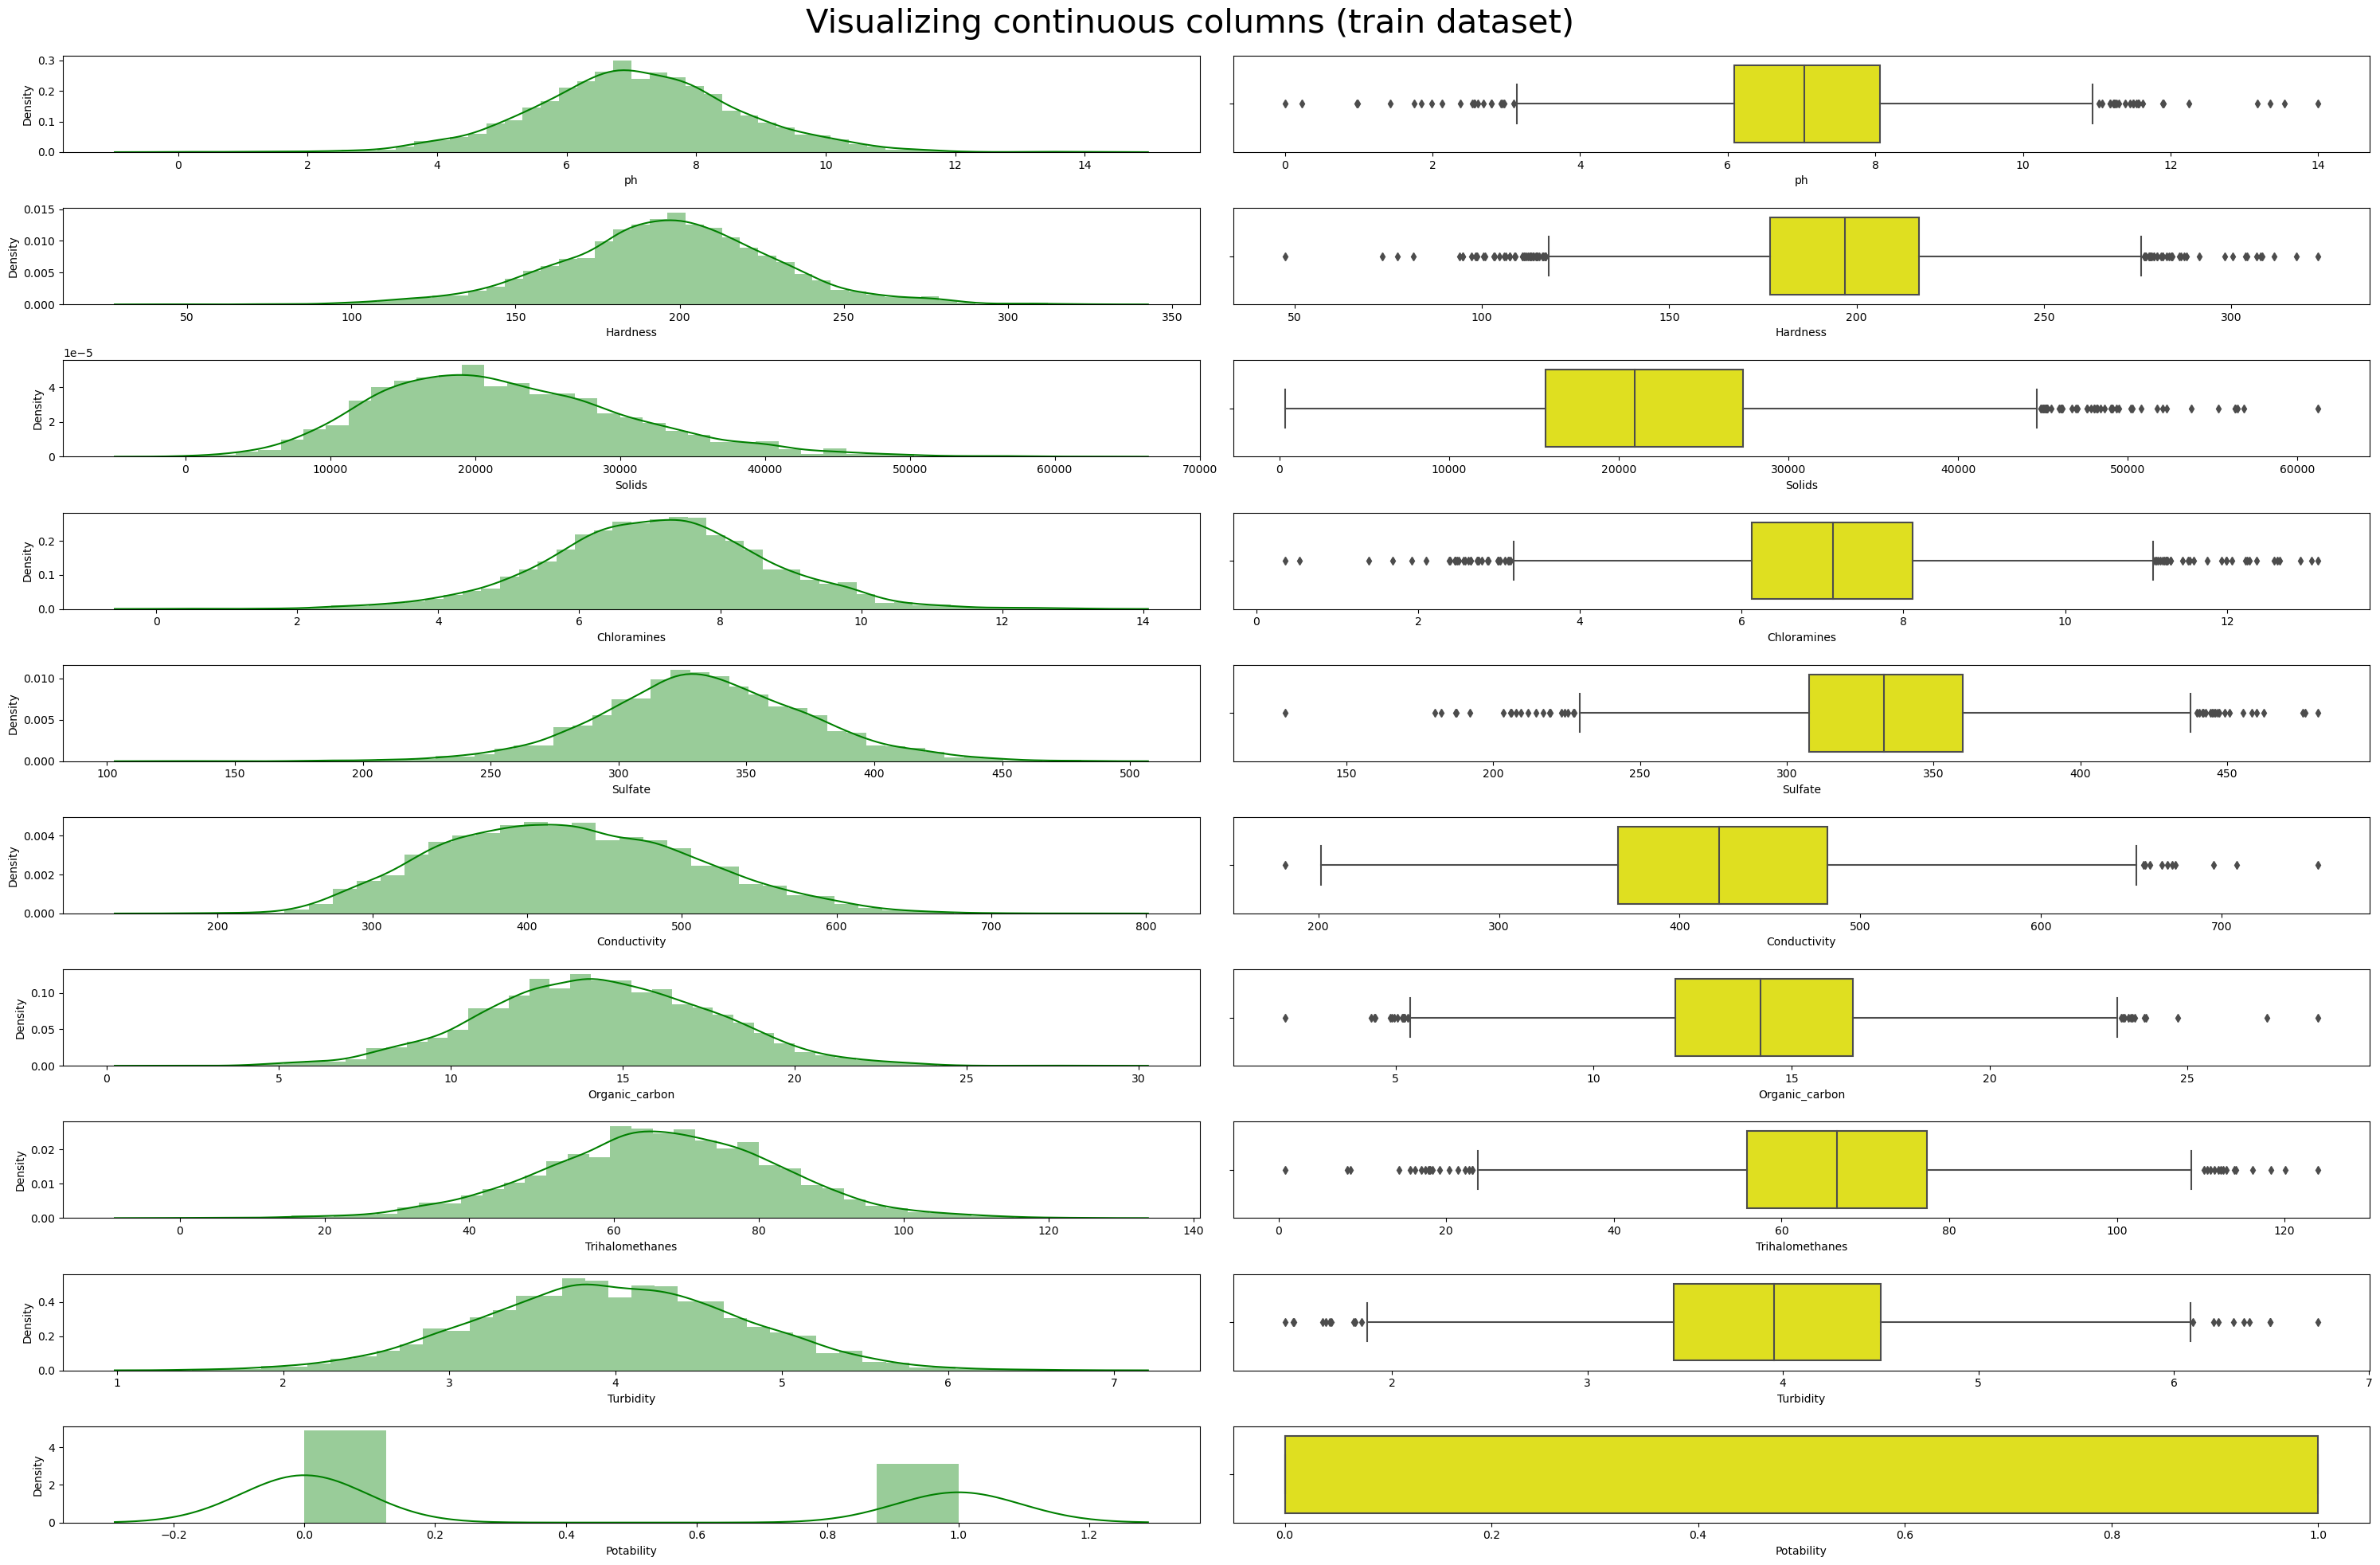

In [11]:
warnings.filterwarnings('ignore')
fig,ax = plt.subplots(len(ds.columns),2,figsize=(30,20))
for index,i in enumerate(ds.columns):
    sns.distplot(ds[i],ax=ax[index,0],color='green')
    sns.boxplot(x=ds[i],ax=ax[index,1],color='yellow')
   # sns.violinplot(dataset[i],ax=ax[index,2],color='purple')
   # stats.probplot(ds[i],plot=ax[index,2])

fig.tight_layout()
fig.subplots_adjust(top=0.95)
plt.suptitle("Visualizing continuous columns (train dataset)",fontsize=30)

### 2. Imputing the missing values with the mean

In [12]:
ds['ph']=ds['ph'].fillna(ds.groupby(['Potability'])['ph'].transform('mean')) #median
ds['Sulfate']=ds['Sulfate'].fillna(ds.groupby(['Potability'])['Sulfate'].transform('mean'))
ds['Trihalomethanes']=ds['Trihalomethanes'].fillna(ds.groupby(['Potability'])['Trihalomethanes'].transform('mean'))

### 3. check null again to see any more missing data

In [13]:
print(ds.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


<Axes: >

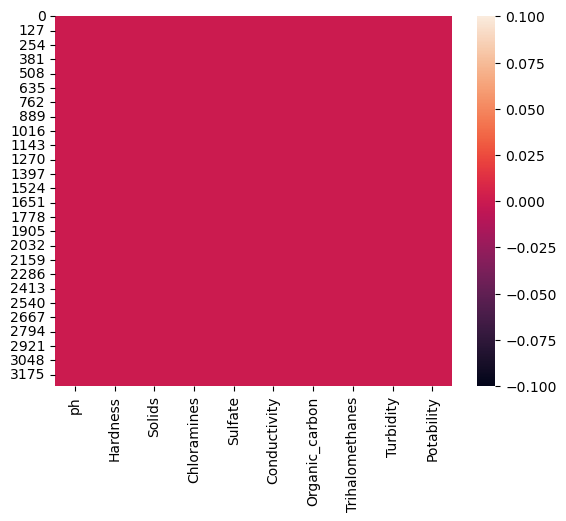

In [14]:
sns.heatmap(ds.isnull())

### 4. check outliers

In [15]:
# columns = [ 'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
#        'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']
for col in ds.columns:
    # calculate interquartile range
    q25, q75 = np.percentile(ds[col], 25), np.percentile(ds[col], 75)
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    lower, upper = q25 - cut_off, q75 + cut_off
    # identify outliers
    outliers = ( ( ds[col] < lower) | (ds[col] > upper) )
    index_label = ds[outliers].index
    print(f'Number of outliers in {col}: {len(index_label)}')
   # ds.drop(index_label, inplace=True)

Number of outliers in ph: 142
Number of outliers in Hardness: 83
Number of outliers in Solids: 47
Number of outliers in Chloramines: 61
Number of outliers in Sulfate: 264
Number of outliers in Conductivity: 11
Number of outliers in Organic_carbon: 25
Number of outliers in Trihalomethanes: 54
Number of outliers in Turbidity: 19
Number of outliers in Potability: 0


Text(0.5, 0.98, 'Visualizing continuous columns (train dataset)')

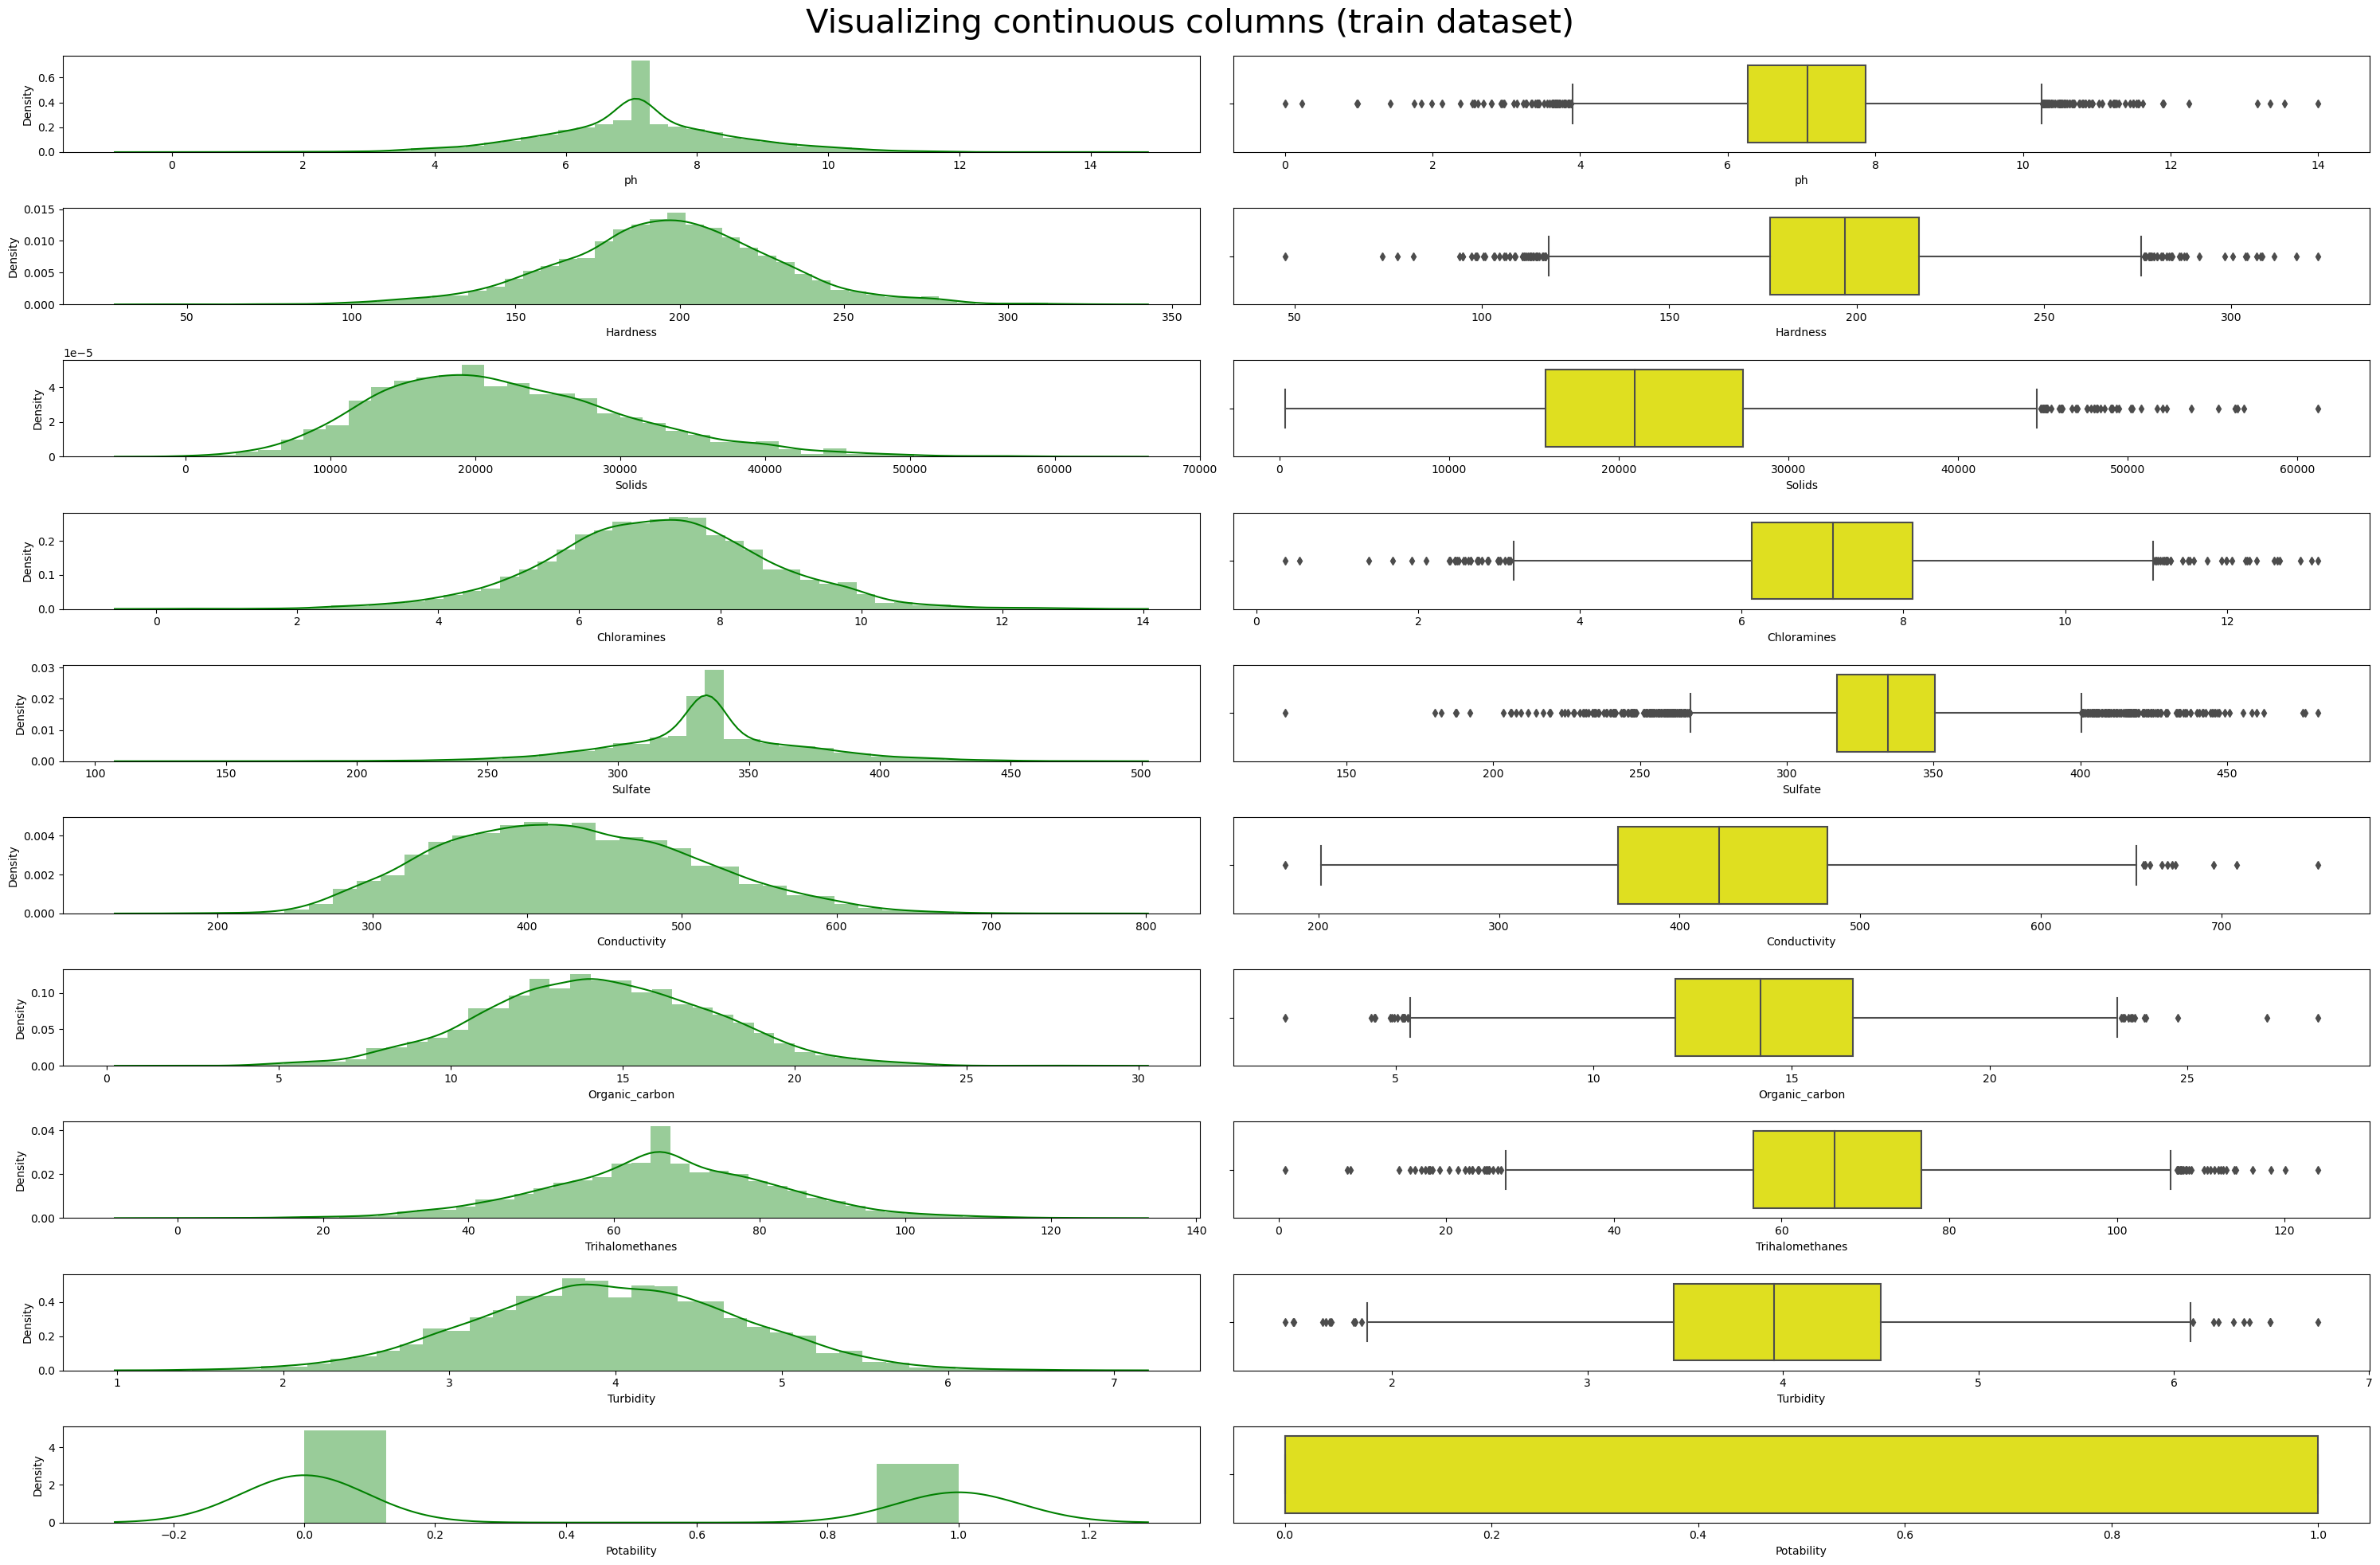

In [16]:
warnings.filterwarnings('ignore')
fig,ax = plt.subplots(len(ds.columns),2,figsize=(30,20))
for index,i in enumerate(ds.columns):
    sns.distplot(ds[i],ax=ax[index,0],color='green')
    sns.boxplot(x=ds[i],ax=ax[index,1],color='yellow')
   # sns.violinplot(dataset[i],ax=ax[index,2],color='purple')
   # stats.probplot(ds[i],plot=ax[index,2])

fig.tight_layout()
fig.subplots_adjust(top=0.95)
plt.suptitle("Visualizing continuous columns (train dataset)",fontsize=30)

### 5. identifying outliers

In [17]:
num_col = (ds.columns).to_list()
num_col = num_col[0:]

def outliers(ds, column):
    Q1 = ds[column].quantile(0.25)
    Q3 = ds[column].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    for i in range(len(ds)):
        if ds[column].iloc[i] > upper_bound:
            ds[column].iloc[i] = upper_bound
        if ds[column].iloc[i] < lower_bound:
            ds[column].iloc[i] = lower_bound
            
for feature in num_col:
    outliers(ds, feature)


### 6. check outliers again

In [18]:
# columns = [ 'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
#        'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']
for col in ds.columns:
    # calculate interquartile range
    q25, q75 = np.percentile(ds[col], 25), np.percentile(ds[col], 75)
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    lower, upper = q25 - cut_off, q75 + cut_off
    # identify outliers
    outliers = ( ( ds[col] < lower) | (ds[col] > upper) )
    index_label = ds[outliers].index
    print(f'Number of outliers in {col}: {len(index_label)}')

Number of outliers in ph: 0
Number of outliers in Hardness: 0
Number of outliers in Solids: 0
Number of outliers in Chloramines: 0
Number of outliers in Sulfate: 0
Number of outliers in Conductivity: 0
Number of outliers in Organic_carbon: 0
Number of outliers in Trihalomethanes: 0
Number of outliers in Turbidity: 0
Number of outliers in Potability: 0


Text(0.5, 0.98, 'Visualizing continuous columns (train dataset)')

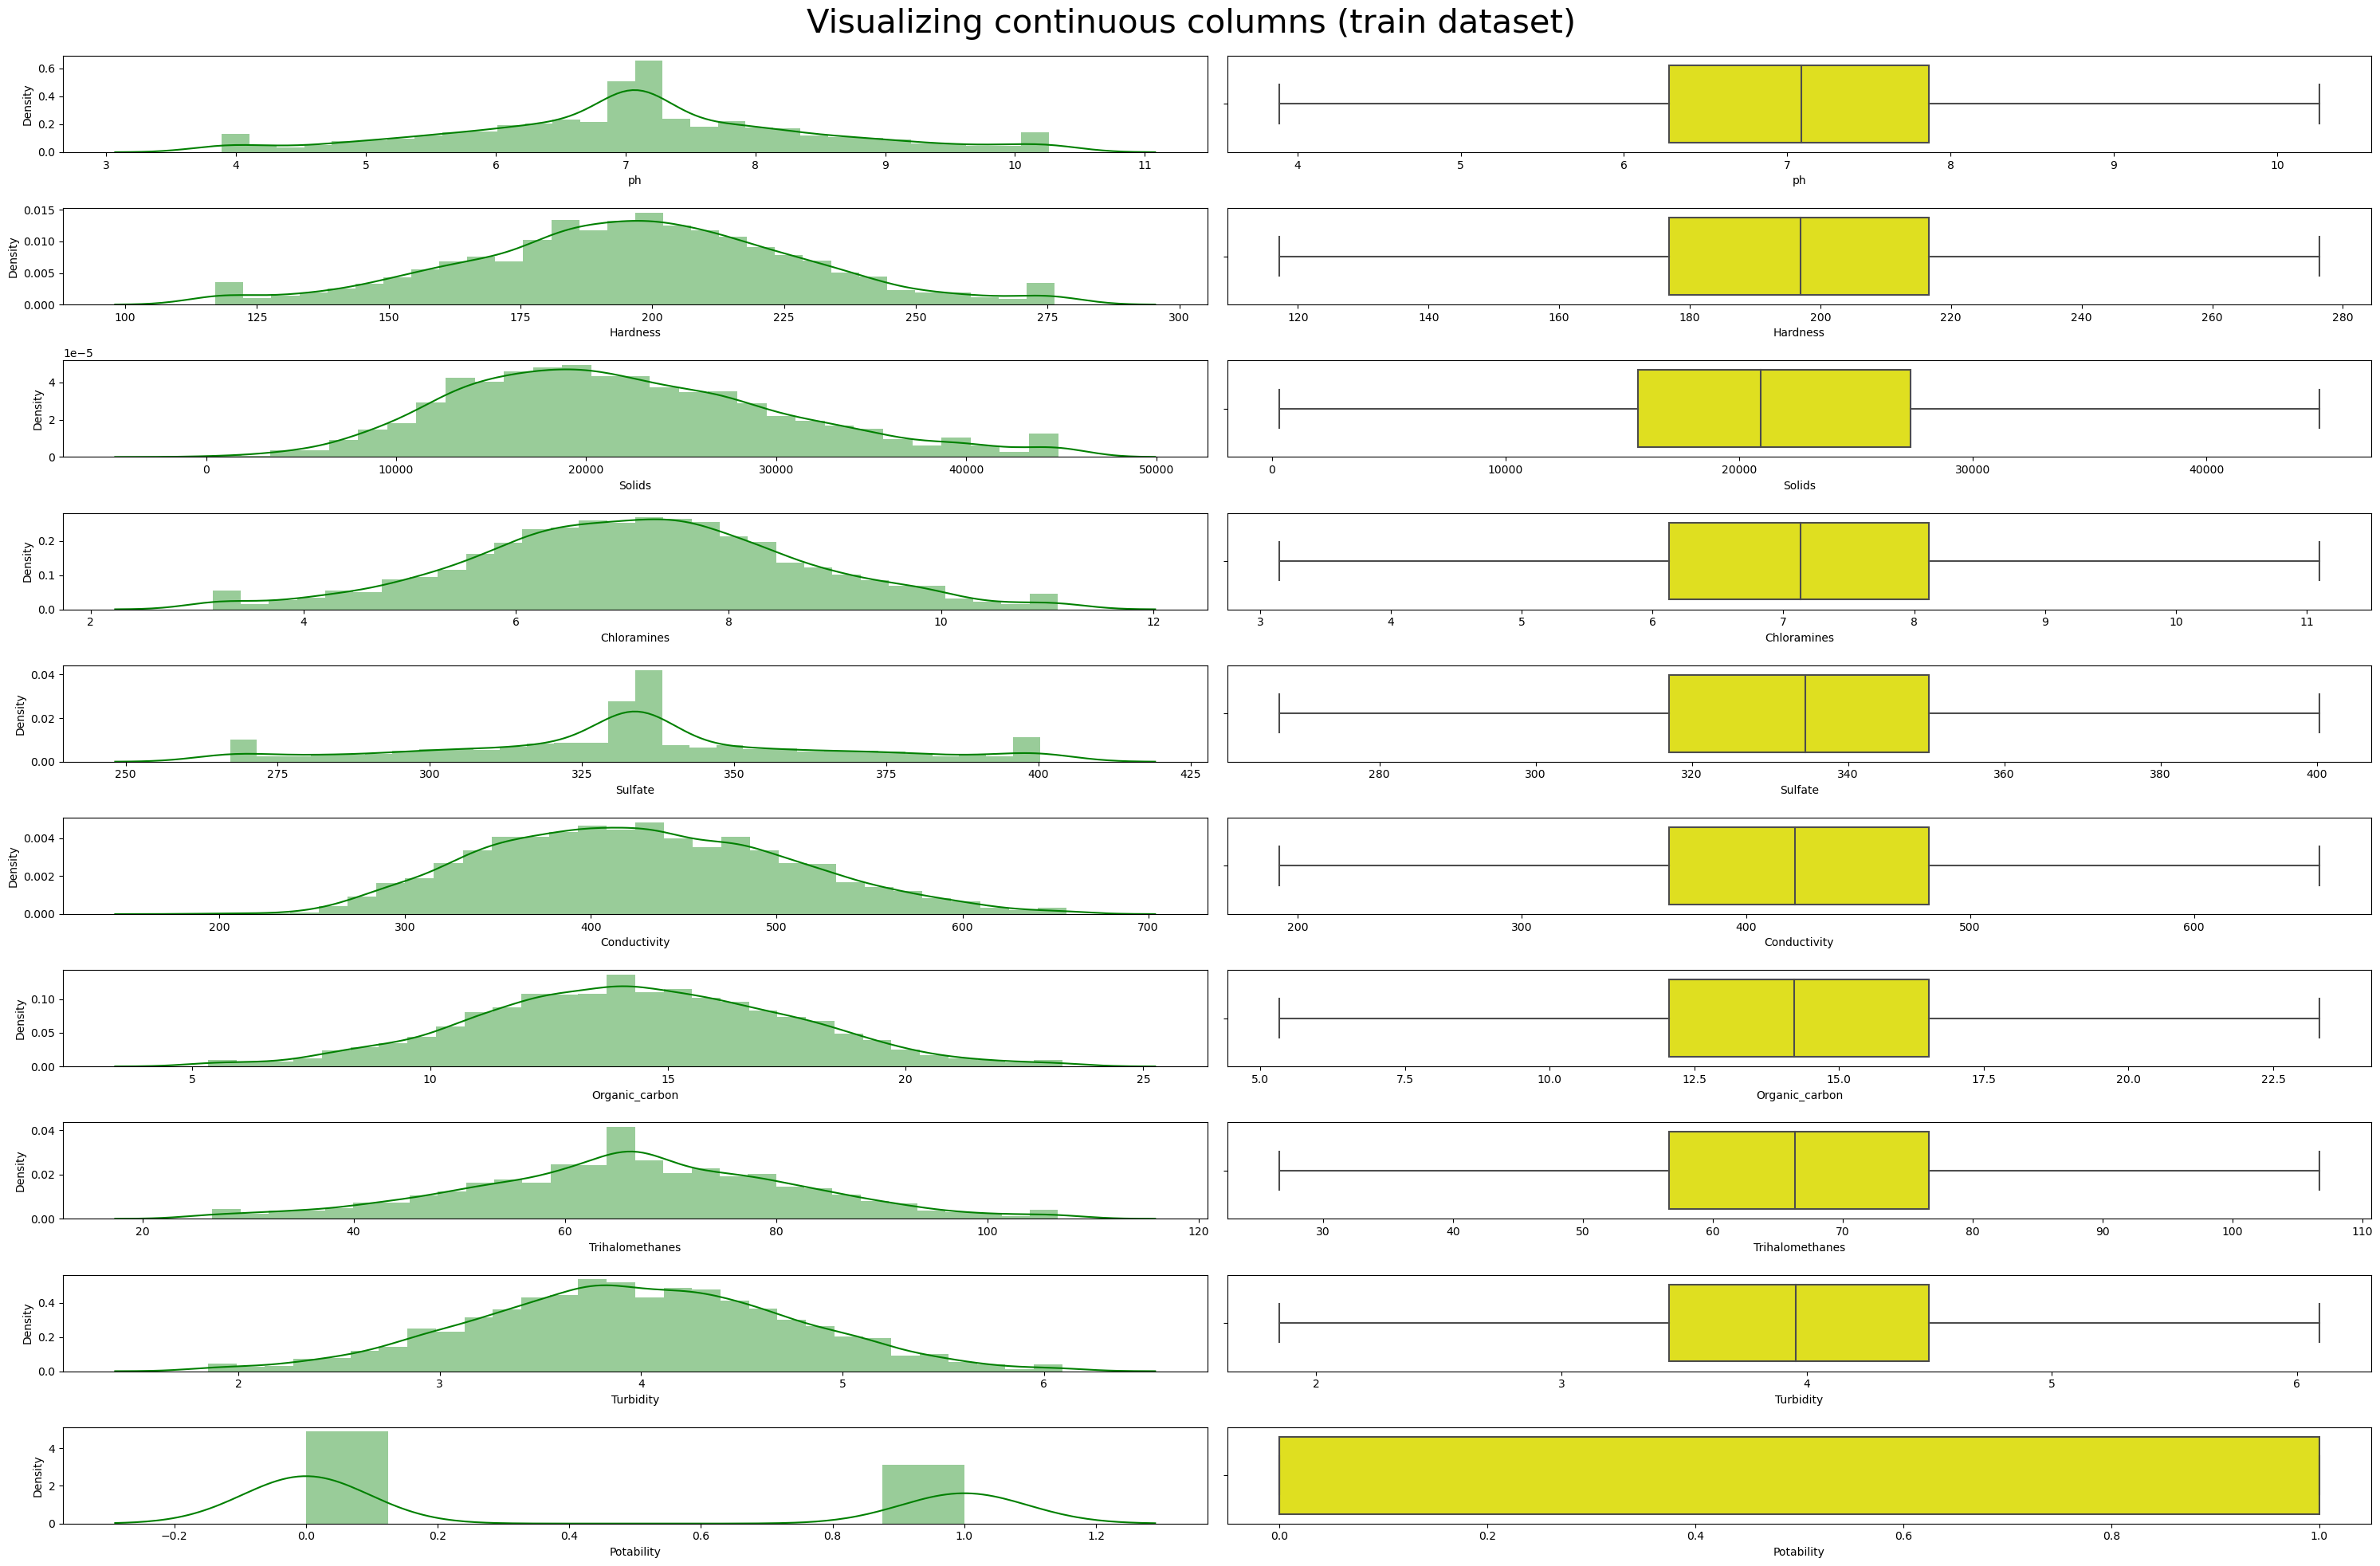

In [19]:
warnings.filterwarnings('ignore')
fig,ax = plt.subplots(len(ds.columns),2,figsize=(30,20))
for index,i in enumerate(ds.columns):
    sns.distplot(ds[i],ax=ax[index,0],color='green')
    sns.boxplot(x=ds[i],ax=ax[index,1],color='yellow')
   # sns.violinplot(dataset[i],ax=ax[index,2],color='purple')
   # stats.probplot(ds[i],plot=ax[index,2])

fig.tight_layout()
fig.subplots_adjust(top=0.95)
plt.suptitle("Visualizing continuous columns (train dataset)",fontsize=30)

### 7. show data after correct data

In [20]:
ds.head(10)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.085378,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.889107,129.422921,18630.057858,6.635246,334.564290,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,334.564290,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,7.085378,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,10.258615,227.231469,25484.508491,9.077200,400.322434,563.885481,17.927806,71.976601,4.370562,0


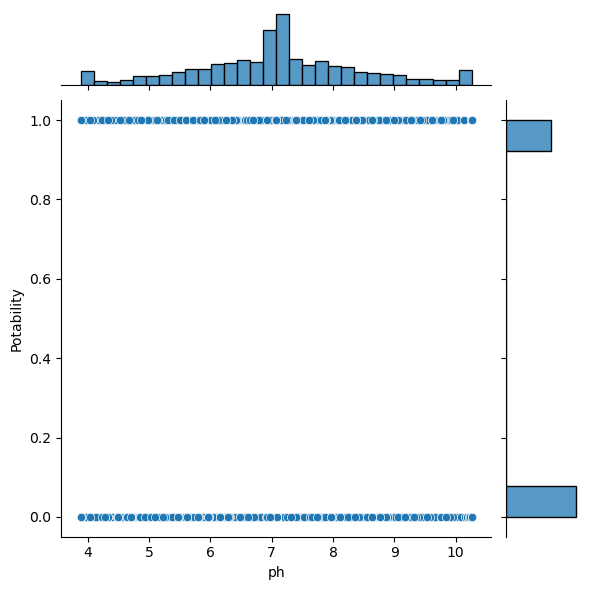

In [21]:
sns.jointplot(x='ph',y='Potability',data=ds ,kind='scatter' )

### 8. check dublicated

In [22]:
print(ds.duplicated().sum())

0


### 9. Feather selection

Check for Correlation

<Axes: >

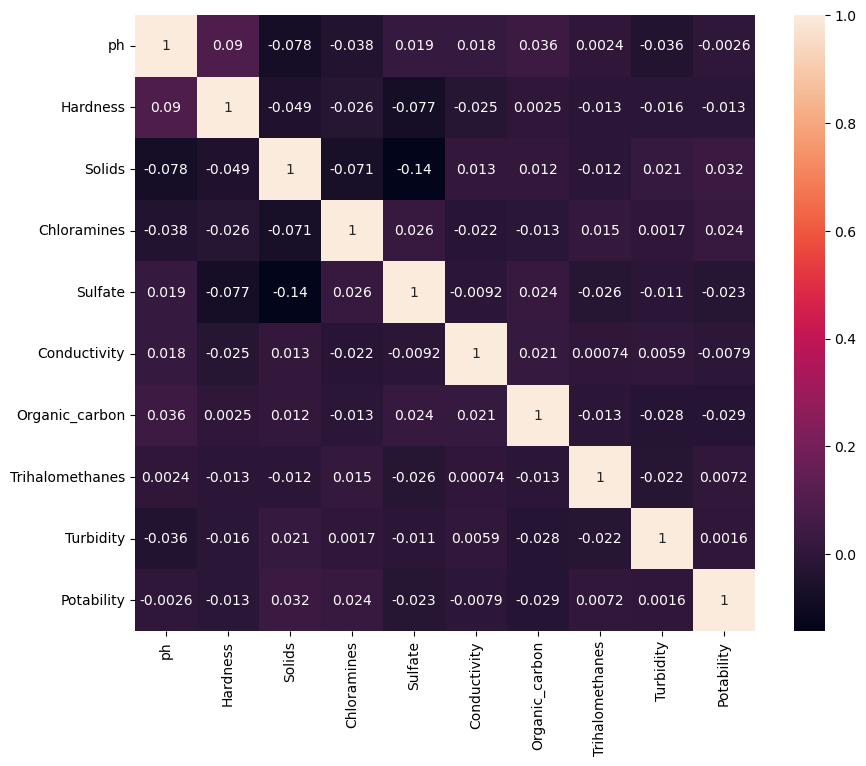

In [23]:
ds.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ds.corr(),annot = True, ax =ax)

### 10. show Pairplots

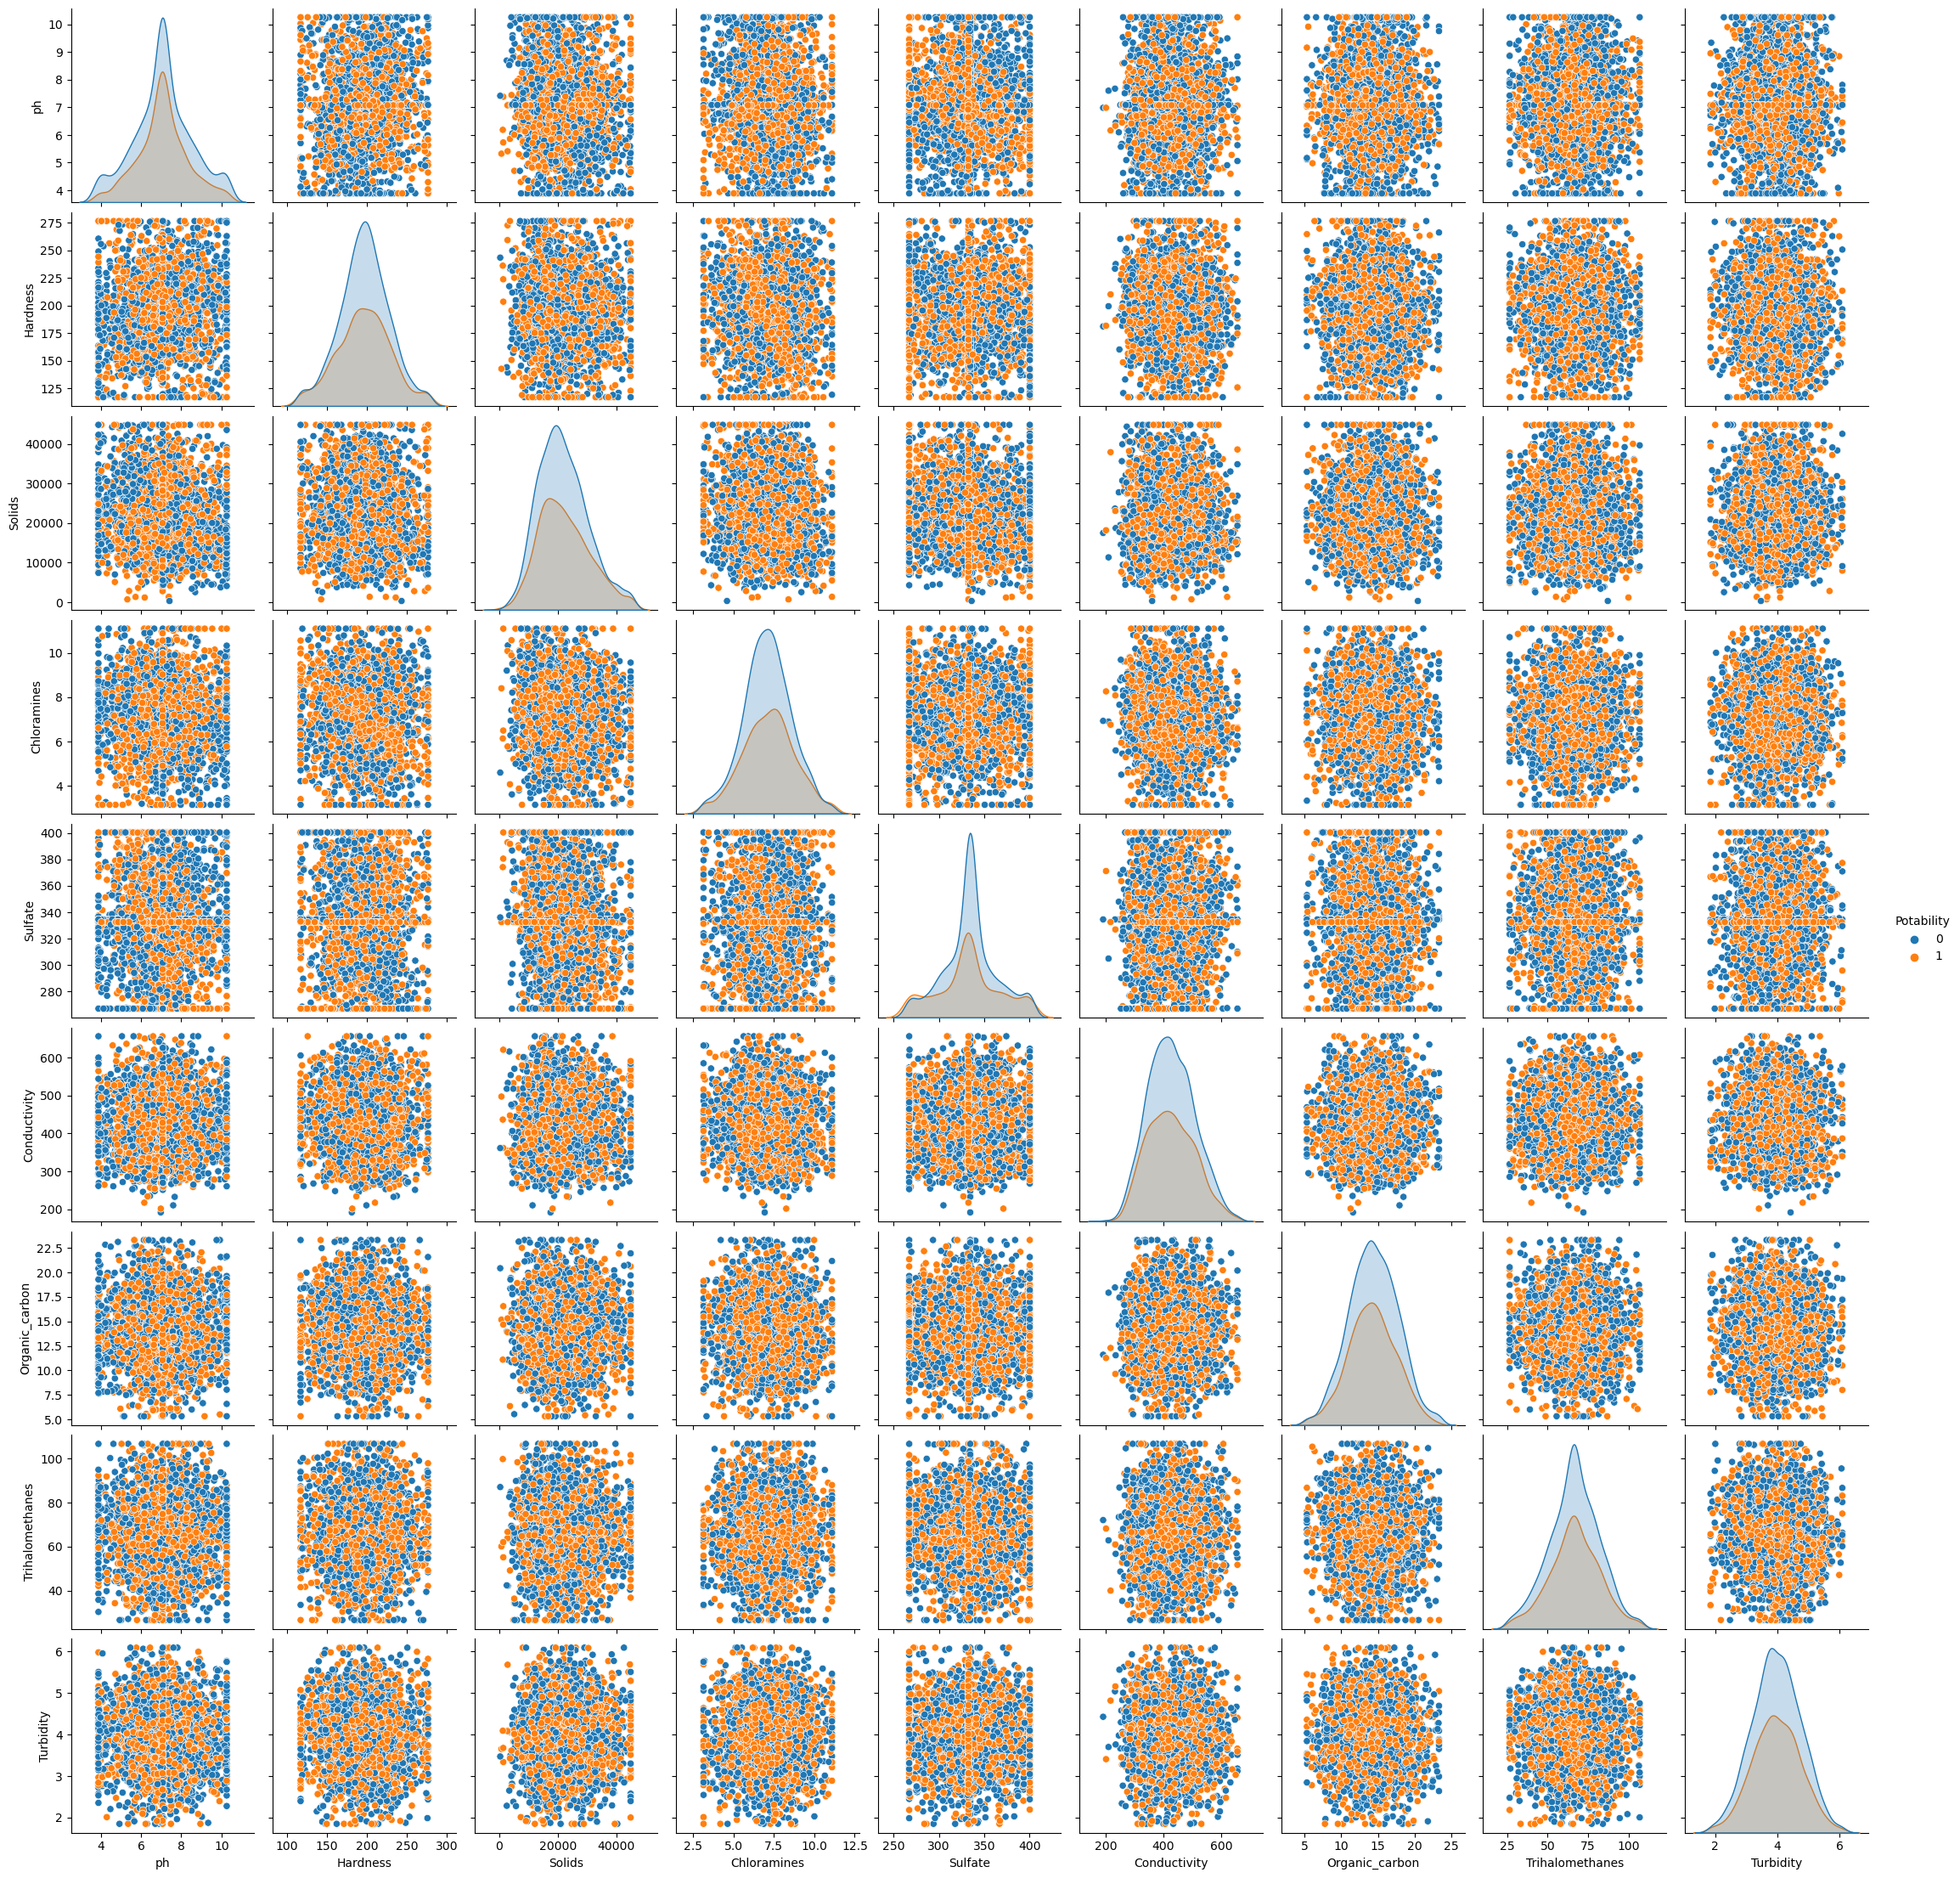

In [24]:
sns.pairplot(ds, hue="Potability")

### 11. divid data to x,y

In [25]:
y = ds['Potability']
X = ds.drop(['Potability'], axis=1)

chek py selectKBest

In [26]:
# X_new=SelectKBest(chi2,k=8).fit_transform(X,y)

In [27]:
# X_new.shape

### 12. show information for Potability


In [28]:
# plt.figure(figsize=(5, 5))
# sns.countplot(x="Potability", data=ds, palette='husl');

#import plotly.express as px
#fig =  px.pie (ds, names = "Potability", hole = 0.4, template = "plotly_dark")
#fig.show ()

In [29]:
ds.Potability.value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

Text(0.5, 1.0, 'Potability')

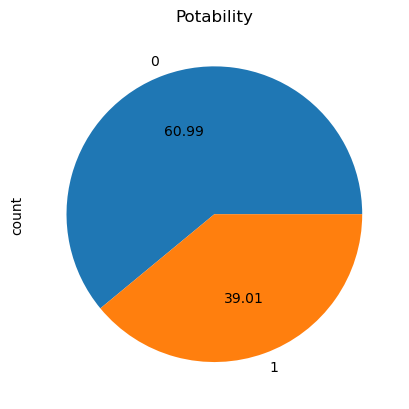

In [30]:
ds['Potability'].value_counts().plot.pie(autopct='%.2f').set_title("Potability")

### 13. oversampling data

Text(0.5, 1.0, 'Potability')

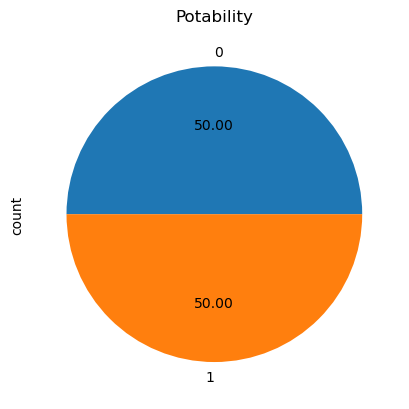

In [31]:
rus =RandomOverSampler(sampling_strategy=1)
x_res, y_res = rus.fit_resample(X,y)
y_res.value_counts().plot.pie(autopct='%.2f').set_title("Potability")

In [32]:
y_res.value_counts()

Potability
0    1998
1    1998
Name: count, dtype: int64

### 14. Split data

In [102]:
X_train,X_test, y_train, y_test = train_test_split(x_res,y_res, test_size=0.07, random_state=30)

In [103]:
# print('Balancing the data by SMOTE - Oversampling of Minority level\n')
# smt = SMOTE()
# counter = Counter(y_train)
# print('Before SMOTE', counter)
# X_train, y_train = smt.fit_resample(X_train, y_train)
# counter = Counter(y_train)
# print('\nAfter SMOTE', counter)

### 15. scale data

In [104]:
standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train) #["Hardness"]
X_test = standard_scaler.transform(X_test)

## 2) Implement the classification models

### 1. Logistic Regression

In [36]:
range_LogisticRegression=range(1,20)
accuracy_LogisticRegression=[]
for i in range_LogisticRegression:
    model_test=LogisticRegression (solver= 'liblinear',C=i)
    model_test.fit(X_train,y_train)
    y_pred_LogisticRegression=model_test.predict(X_test)
    val_accuracy_LogisticRegression = accuracy_score_LogisticRegression=accuracy_score(y_test,y_pred_LogisticRegression)
    accuracy_LogisticRegression.append(val_accuracy_LogisticRegression)

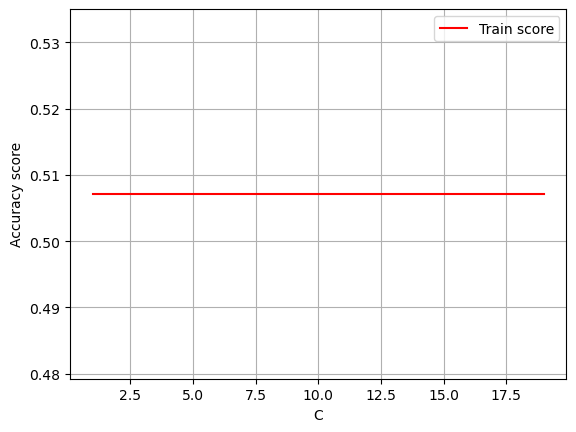

In [37]:
#plt.plot(max_depth_range, val_results, 'g-', label='Val score')
plt.plot(range_LogisticRegression, accuracy_LogisticRegression, 'r-', label='Train score')
plt.ylabel('Accuracy score')
plt.xlabel('C')
plt.legend()
plt.grid(True)
plt.show()

In [105]:
lr_model = LogisticRegression (solver= 'liblinear')

In [106]:
lr_model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [107]:
#make prediction
P_pred_logistic = lr_model.predict_proba(X_test)
y_pred_logistic = lr_model.predict (X_test)

In [108]:
report_logistic = classification_report (y_test,y_pred_logistic)

In [109]:
print('report:',report_logistic,sep='\n')

report:
              precision    recall  f1-score   support

           0       0.48      0.50      0.49       136
           1       0.51      0.49      0.50       144

    accuracy                           0.49       280
   macro avg       0.49      0.49      0.49       280
weighted avg       0.49      0.49      0.49       280



In [136]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print("Accuracy of LogisticRegression:", accuracy_logistic)
#0.5015 when using mean and scaling

Accuracy of LogisticRegression: 0.4928571428571429


In [137]:
print('Predicted Probabilities for LogisticRegressuinModel is :',P_pred_logistic[:10])

Predicted Probabilities for LogisticRegressuinModel is : [[0.50305344 0.49694656]
 [0.48724123 0.51275877]
 [0.46667081 0.53332919]
 [0.46984987 0.53015013]
 [0.50860793 0.49139207]
 [0.48249227 0.51750773]
 [0.44014393 0.55985607]
 [0.47206897 0.52793103]
 [0.51746083 0.48253917]
 [0.46512869 0.53487131]]


In [138]:
print('Predicted Value for LogisticRegressuinModel is :',y_pred_logistic[:10])

Predicted Value for LogisticRegressuinModel is : [0 1 1 1 0 1 1 1 0 1]


In [139]:
conf_matrix = confusion_matrix(y_test, y_pred_logistic)

In [140]:
print('conf_matrix :',conf_matrix,sep='\n',end='\n\n')

conf_matrix :
[[68 68]
 [74 70]]



In [141]:
score_ = lr_model.score(X_train, y_train)

In [142]:
print('Logistic Resgression Train Score is :',score_,end='\n\n')

Logistic Resgression Train Score is : 0.5172228202368138



In [143]:
score_ = lr_model.score(X_test, y_test)

In [144]:
print('Logistic Resgression Test Score is :',score_,end='\n\n')

Logistic Resgression Test Score is : 0.4928571428571429



### 2. SVM

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


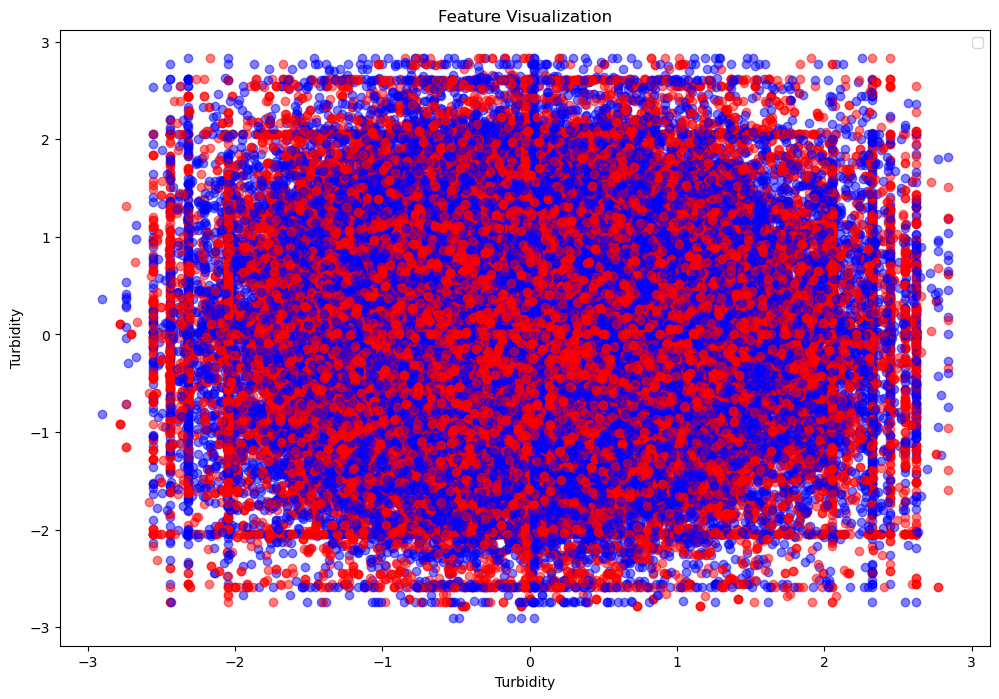

In [52]:
import numpy as np
import matplotlib.pyplot as plt


# Get feature names
features = ['Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

# Create scatter plot for each pair of features
plt.figure(figsize=(12, 8))
for i in range(len(features)):
    for j in range(i + 1, len(features)):
        plt.scatter(X_train[y_train == 0, i], X_train[y_train == 0, j], c='blue', alpha=0.5)
        plt.scatter(X_train[y_train == 1, i], X_train[y_train == 1, j], c='red', alpha=0.5)

plt.xlabel(features[i])
plt.ylabel(features[j])
plt.title('Feature Visualization')
plt.legend()
plt.show()

In [53]:
range_svm=range(1,50)
test_results_svm = []
train_results_svm = []
for i in range_svm:
    model_test=SVC(kernel="rbf",C=i)
    model_test.fit(X_train,y_train)
    #accuracy on training
    y_pred_train_svm=model_test.predict(X_train)
    val_accuracy_train_svm = accuracy_score_svm=accuracy_score(y_train,y_pred_train_svm)
    train_results_svm.append(val_accuracy_train_svm)
    #accuracy on validation data
    y_pred_svm=model_test.predict(X_test)
    val_accuracy_svm = accuracy_score_svm=accuracy_score(y_test,y_pred_svm)
    test_results_svm.append(val_accuracy_svm)
    

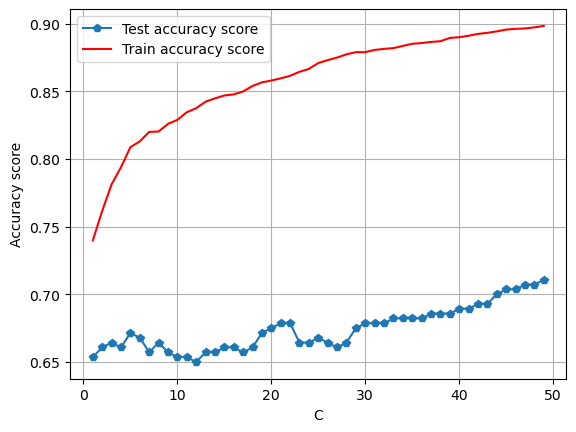

In [54]:
plt.plot(range_svm, test_results_svm, 'p-', label='Test accuracy score')
plt.plot(range_svm, train_results_svm, 'r-', label='Train accuracy score')
plt.ylabel('Accuracy score')
plt.xlabel('C')
plt.legend()
plt.grid(True)
plt.show()

In [110]:
svm_model = SVC(kernel="rbf",C=17) #c= 45 oversampling + scale

In [111]:
#model training
svm_model.fit(X_train, y_train)

SVC(C=17)

In [112]:
#make prediction
y_pred_svm=svm_model.predict(X_test)

In [113]:
report_svm = classification_report (y_test, y_pred_svm)

In [114]:
print('report:',report_svm,sep='\n')

report:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72       136
           1       0.74      0.67      0.70       144

    accuracy                           0.71       280
   macro avg       0.71      0.71      0.71       280
weighted avg       0.71      0.71      0.71       280



In [129]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy of SVM:", accuracy_svm)
#0.7359375 when using mean and scaling

Accuracy of SVM: 0.7107142857142857


In [130]:
conf_matrix = confusion_matrix(y_test, y_pred_svm)

In [131]:
print('conf_matrix :',conf_matrix,sep='\n',end='\n\n')

conf_matrix :
[[103  33]
 [ 48  96]]



In [132]:
score_ = svm_model.score(X_train, y_train)

In [133]:
print('SVM Train Score is :',score_,end='\n\n')

SVM Train Score is : 0.8487621097954791



In [134]:
score_ = svm_model.score(X_test, y_test)

In [135]:
print('SVM Test Score is :',score_,end='\n\n')

SVM Test Score is : 0.7107142857142857



### 3. Decision Tree

In [67]:
X_train_new, X_val, y_train_new, y_val = model_selection.train_test_split(X_train, y_train, test_size=0.1, random_state=16)

In [68]:
max_depth_range = range(1, 16)
val_results = []
train_results = []
for k in max_depth_range:
    model_test = DecisionTreeClassifier(max_depth=k)
    model_test = model_test.fit(X_train_new, y_train_new)
    #accuracy on training
    pred_train_new = model_test.predict(X_train_new)
    train_score = metrics.accuracy_score(y_train_new, pred_train_new)
    train_results.append(train_score)
    #accuracy on validation data
    pred_val = model_test.predict(X_val)
    val_score = metrics.accuracy_score(y_val, pred_val)
    val_results.append(val_score)

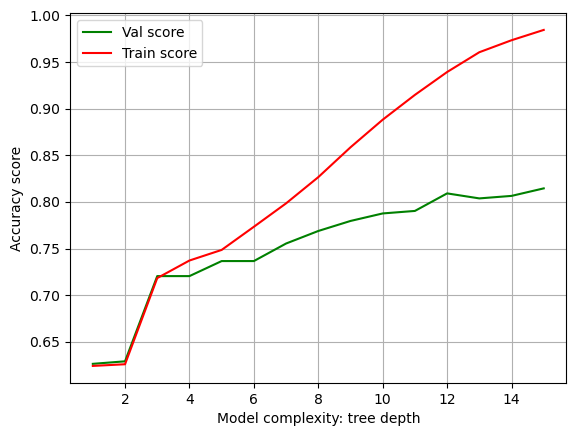

In [69]:
plt.plot(max_depth_range, val_results, 'g-', label='Val score')
plt.plot(max_depth_range, train_results, 'r-', label='Train score')
plt.ylabel('Accuracy score')
plt.xlabel('Model complexity: tree depth')
plt.legend()
plt.grid(True)
plt.show()

In [115]:
dt_model = DecisionTreeClassifier(max_depth=4)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [116]:
y_pred_DecisionTree = dt_model.predict(X_test)


In [117]:
report_DecisionTree = classification_report (y_test,y_pred_DecisionTree)
print('report:',report_DecisionTree,sep='\n')

report:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75       136
           1       0.78      0.70      0.74       144

    accuracy                           0.74       280
   macro avg       0.75      0.74      0.74       280
weighted avg       0.75      0.74      0.74       280



In [118]:
accuracy_DecisionTree = accuracy_score(y_test, y_pred_DecisionTree)
print("Accuracy of DecisionTree:", accuracy_DecisionTree)
#0.725 when using mean and scaling

Accuracy of DecisionTree: 0.7428571428571429


### 4. K-Nearest Neighbors

In [74]:
range_knn=range(1,17,2)
accuracy_knn=[]
for i in range_knn:
    model_test=KNeighborsClassifier(n_neighbors=i)
    model_test.fit(X_train,y_train)
    y_pred_kNN=model_test.predict(X_test)
    val_accuracy_knn = accuracy_score_kNN=accuracy_score(y_test,y_pred_kNN)
    accuracy_knn.append(val_accuracy_knn)

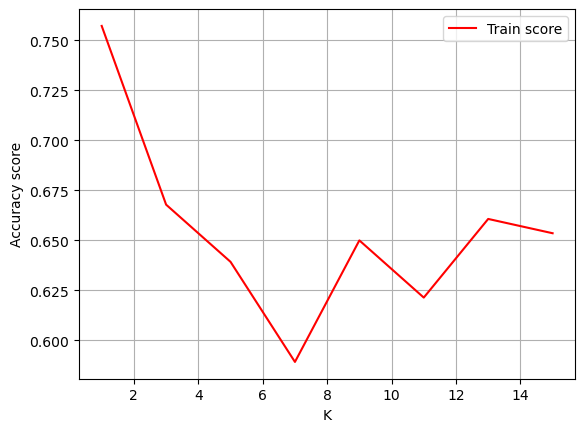

In [75]:
#plt.plot(max_depth_range, val_results, 'g-', label='Val score')
plt.plot(range_knn, accuracy_knn, 'r-', label='Train score')
plt.ylabel('Accuracy score')
plt.xlabel('K')
plt.legend()
plt.grid(True)
plt.show()

In [119]:
knn_model=KNeighborsClassifier(n_neighbors=3)

In [120]:
knn_model.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

#Performance Evaluation

In [121]:
y_pred_knn=knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy of Knn:", accuracy_knn)
#0.665625 when using mean and scaling

Accuracy of Knn: 0.7214285714285714


In [122]:
report_knn=classification_report(y_test, y_pred_knn)
print(report_knn)

              precision    recall  f1-score   support

           0       0.71      0.71      0.71       136
           1       0.73      0.73      0.73       144

    accuracy                           0.72       280
   macro avg       0.72      0.72      0.72       280
weighted avg       0.72      0.72      0.72       280



### 5. Random Forest

In [80]:
range_random_forest=range(1,350,10)
accuracy_random_forest=[]
for i in range_random_forest:
    model_test2=RandomForestClassifier(n_estimators=i)
    model_test2.fit(X_train,y_train)
    y_pred_random_forest=model_test2.predict(X_test)
    val_accuracy_random_forest = accuracy_score_random_forest=accuracy_score(y_test,y_pred_random_forest)
    accuracy_random_forest.append(val_accuracy_random_forest)

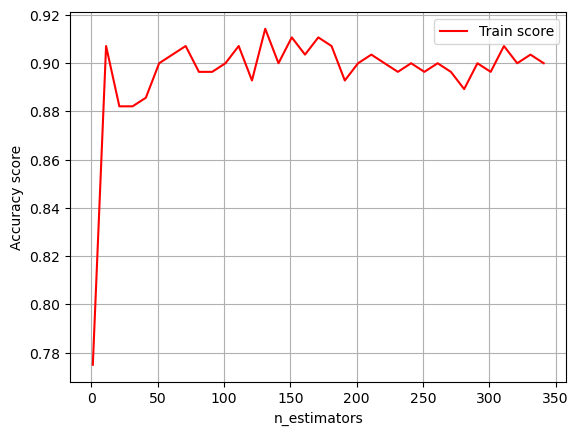

In [81]:
plt.plot(range_random_forest, accuracy_random_forest, 'r-', label='Train score')
plt.ylabel('Accuracy score')
plt.xlabel('n_estimators')
plt.legend()
plt.grid(True)
plt.show()

In [82]:
range_random_forest=range(90,120)
accuracy_random_forest=[]
for i in range_random_forest:
    model_test2=RandomForestClassifier(n_estimators=i)
    model_test2.fit(X_train,y_train)
    y_pred_random_forest=model_test2.predict(X_test)
    val_accuracy_random_forest = accuracy_score_random_forest=accuracy_score(y_test,y_pred_random_forest)
    accuracy_random_forest.append(val_accuracy_random_forest)

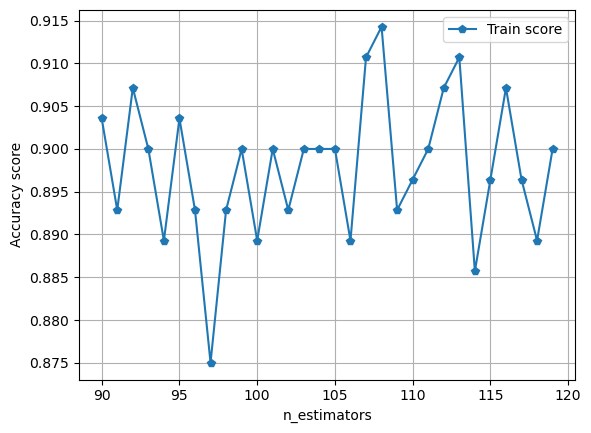

In [83]:
plt.plot(range_random_forest, accuracy_random_forest, 'p-', label='Train score')
plt.ylabel('Accuracy score')
plt.xlabel('n_estimators')
plt.legend()
plt.grid(True)
plt.show()

In [123]:
# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100)#345 in oversampling without scale #151 is good

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [124]:
# Making predictions
y_pred_RandomForest = rf_model.predict(X_test)

# Evaluating the model
accuracy_RandomForest = accuracy_score(y_test, y_pred_RandomForest)
print("Accuracy of RandomForest:", accuracy_RandomForest)

#0.8828 when using mean and scaling


Accuracy of RandomForest: 0.9107142857142857


In [125]:
report_RandomForest = classification_report (y_test,y_pred_RandomForest)
print('report:',report_RandomForest,sep='\n')

report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       136
           1       0.92      0.90      0.91       144

    accuracy                           0.91       280
   macro avg       0.91      0.91      0.91       280
weighted avg       0.91      0.91      0.91       280



### 6. XGBoost

In [126]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(learning_rate=0.5,colsample_bytree=0.8)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [127]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("Accuracy of XGBoost:", accuracy_xgb)

Accuracy of XGBoost: 0.9071428571428571


In [128]:
report_xgb = classification_report (y_test,y_pred_xgb)
print('report:',report_xgb,sep='\n')

report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       136
           1       0.89      0.93      0.91       144

    accuracy                           0.91       280
   macro avg       0.91      0.91      0.91       280
weighted avg       0.91      0.91      0.91       280



In [145]:
models_accuracy= pd.DataFrame({
    "Model": [ 
        "Logistic Regression",
        "SVM",
        "Decision Tree",
        "KNN",
        "Random Forest",
        "XGBoost"
        ],
    "Accuracy Score" : [
        accuracy_logistic,
        accuracy_svm,
        accuracy_DecisionTree,
        accuracy_knn,
        accuracy_RandomForest,
        accuracy_xgb
    ]
})

In [146]:
models_accuracy

,Model,Accuracy Score
0,Logistic Regression,0.492857
1,SVM,0.710714
2,Decision Tree,0.742857
3,KNN,0.721429
4,Random Forest,0.910714
5,XGBoost,0.907143


,Model,Accuracy Score
4,Random Forest,0.910714
5,XGBoost,0.907143
2,Decision Tree,0.742857
3,KNN,0.721429
1,SVM,0.710714
0,Logistic Regression,0.492857


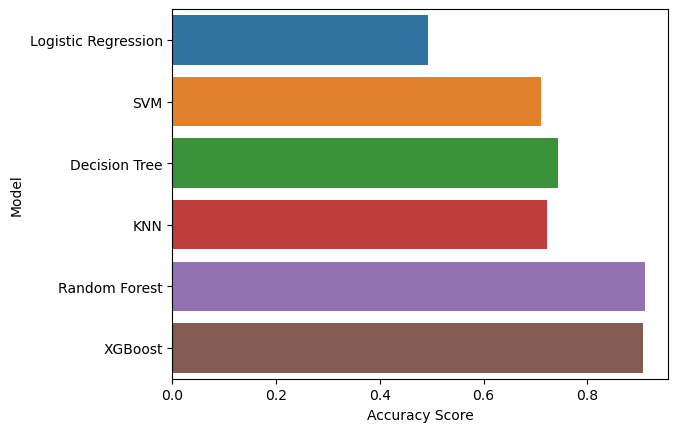

In [147]:
sns.barplot(y = "Model", x = "Accuracy Score",data = models_accuracy)  
models_accuracy.sort_values(by ="Accuracy Score",ascending=False)

In [148]:
print( "Logistic Regression  = ", accuracy_logistic*100)
print( "SVM  = ", accuracy_svm*100)
print( "Decision tree  = ", accuracy_DecisionTree *100 )
print("KNN  = ", accuracy_knn *100)
print("Random Forest  = ", accuracy_RandomForest *100)
print("XGBoost  = ", accuracy_xgb *100)

Logistic Regression  =  49.28571428571429
SVM  =  71.07142857142857
Decision tree  =  74.28571428571429
KNN  =  72.14285714285714
Random Forest  =  91.07142857142857
XGBoost  =  90.71428571428571


# Some tests to increase accuracy

test the best random state

In [94]:
accuracy_logistic_test = []
accuracy_svm_test = []
accuracy_decisionTree_test = []
accuracy_knn_test = []
accuracy_randomForest_test = []
accuracy_xgboost_test = []
max_range_radom_state=range(5,35)
for i in max_range_radom_state:
    X_train,X_test, y_train, y_test = train_test_split(x_res,y_res, test_size=0.2, random_state=i)
    standard_scaler = StandardScaler()
    X_train = standard_scaler.fit_transform(X_train) 
    X_test = standard_scaler.transform(X_test)
    model1 = LogisticRegression()
    model1.fit(X_train,y_train)
    y_pred_model1 = model1.predict(X_test)
    accuracy_model1=accuracy_score(y_test, y_pred_model1)
    accuracy_logistic_test.append(accuracy_model1)
    
    model2 = SVC(kernel="rbf",C=17)
    model2.fit(X_train,y_train)
    y_pred_model2 = model2.predict(X_test)
    accuracy_model2=accuracy_score(y_test, y_pred_model2)
    accuracy_svm_test.append(accuracy_model2)
    
    model3 = DecisionTreeClassifier(max_depth=4)
    model3.fit(X_train, y_train)
    y_pred_model3 = model3.predict(X_test)
    accuracy_model3=accuracy_score(y_test, y_pred_model3)
    accuracy_decisionTree_test.append(accuracy_model3)
    
    
    model4 = KNeighborsClassifier(n_neighbors=3)
    model4.fit(X_train, y_train)
    y_pred_model4 = model4.predict(X_test)
    accuracy_model4=accuracy_score(y_test, y_pred_model4)
    accuracy_knn_test.append(accuracy_model4)
                    
    model5 = RandomForestClassifier(n_estimators=100)
    model5.fit(X_train, y_train)
    y_pred_model5 = model5.predict(X_test)
    accuracy_model5=accuracy_score(y_test, y_pred_model5)
    accuracy_randomForest_test.append(accuracy_model5)
    
    model6 = XGBClassifier(learning_rate=0.5,colsample_bytree=0.8)
    model6.fit(X_train, y_train)
    y_pred_model6 = model6.predict(X_test)
    accuracy_model6=accuracy_score(y_test, y_pred_model6)
    accuracy_xgboost_test.append(accuracy_model6)
    

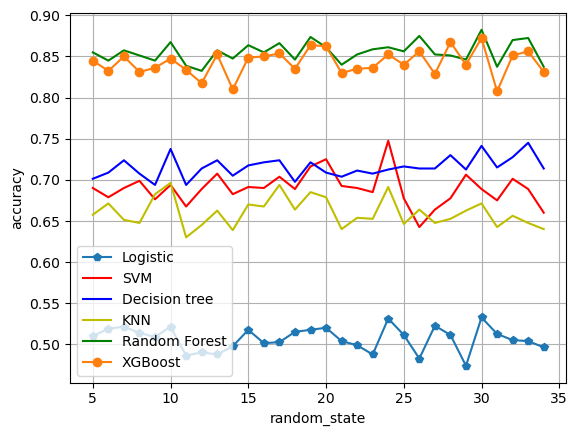

In [95]:
plt.plot(max_range_radom_state, accuracy_logistic_test, 'p-', label='Logistic')
plt.plot(max_range_radom_state, accuracy_svm_test, 'r-', label='SVM')
plt.plot(max_range_radom_state, accuracy_decisionTree_test, 'b-', label='Decision tree')
plt.plot(max_range_radom_state, accuracy_knn_test, 'y-', label='KNN')
plt.plot(max_range_radom_state, accuracy_randomForest_test, 'g-', label='Random Forest')
plt.plot(max_range_radom_state, accuracy_xgboost_test, 'o-', label='XGBoost')



plt.ylabel('accuracy')
plt.xlabel('random_state')
plt.legend()
plt.grid(True)
plt.show()

In [96]:
accuracy_logistic_test = []
accuracy_svm_test = []
accuracy_decisionTree_test = []
accuracy_knn_test = []
accuracy_randomForest_test = []
accuracy_xgboost_test = []
max_range_test_size=range(1,20)
for j in max_range_test_size:
    X_train,X_test, y_train, y_test = train_test_split(x_res,y_res, test_size= j/100, random_state=30)
    standard_scaler = StandardScaler()
    X_train = standard_scaler.fit_transform(X_train) 
    X_test = standard_scaler.transform(X_test)
    model1 = LogisticRegression()
    model1.fit(X_train,y_train)
    y_pred_model1 = model1.predict(X_test)
    accuracy_model1=accuracy_score(y_test, y_pred_model1)
    accuracy_logistic_test.append(accuracy_model1)
    
    model2 = SVC(kernel="rbf",C=17)
    model2.fit(X_train,y_train)
    y_pred_model2 = model2.predict(X_test)
    accuracy_model2=accuracy_score(y_test, y_pred_model2)
    accuracy_svm_test.append(accuracy_model2)
    
    model3 = DecisionTreeClassifier(max_depth=4)
    model3.fit(X_train, y_train)
    y_pred_model3 = model3.predict(X_test)
    accuracy_model3=accuracy_score(y_test, y_pred_model3)
    accuracy_decisionTree_test.append(accuracy_model3)
    
    
    model4 = KNeighborsClassifier(n_neighbors=3)
    model4.fit(X_train, y_train)
    y_pred_model4 = model4.predict(X_test)
    accuracy_model4=accuracy_score(y_test, y_pred_model4)
    accuracy_knn_test.append(accuracy_model4)
                    
    model5 = RandomForestClassifier(n_estimators=100)
    model5.fit(X_train, y_train)
    y_pred_model5 = model5.predict(X_test)
    accuracy_model5=accuracy_score(y_test, y_pred_model5)
    accuracy_randomForest_test.append(accuracy_model5)
    
    model6 = XGBClassifier(learning_rate=0.5,colsample_bytree=0.8)
    model6.fit(X_train, y_train)
    y_pred_model6 = model6.predict(X_test)
    accuracy_model6=accuracy_score(y_test, y_pred_model6)
    accuracy_xgboost_test.append(accuracy_model6)
    

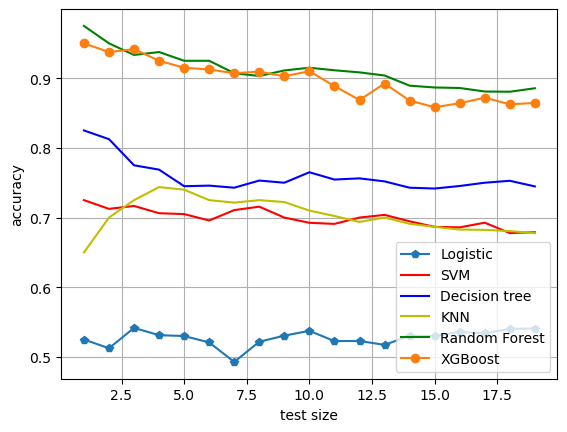

In [97]:
plt.plot(max_range_test_size, accuracy_logistic_test, 'p-', label='Logistic')
plt.plot(max_range_test_size, accuracy_svm_test, 'r-', label='SVM')
plt.plot(max_range_test_size, accuracy_decisionTree_test, 'b-', label='Decision tree')
plt.plot(max_range_test_size, accuracy_knn_test, 'y-', label='KNN')
plt.plot(max_range_test_size, accuracy_randomForest_test, 'g-', label='Random Forest')
plt.plot(max_range_test_size, accuracy_xgboost_test, 'o-', label='XGBoost')

plt.ylabel('accuracy')
plt.xlabel('test size')
plt.legend()
plt.grid(True)
plt.show()